In [1]:
# analysis
import numpy as np
import pandas as pd 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# single-cell
import scanpy as sc
import liana as li
import mudata as mu

from pathlib import Path
import os 

# seting global dir
cwd=Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/MSB'

Analiza multimodalna

In [2]:
# set global figure parameters
kwargs = {'frameon':False, 'size':1.5, 'img_key':'lowres'}

# set global path parameters
PATH_data = Path('data/multimodal')


In [ ]:
# let's download the data
rna = sc.read("sma_rna.h5ad", backup_url="https://figshare.com/ndownloader/files/44624974?private_link=4744950f8768d5c8f68c")
msi = sc.read("sma_msi.h5ad", backup_url="https://figshare.com/ndownloader/files/44624971?private_link=4744950f8768d5c8f68c")
ct = sc.read("sma_ct.h5ad", backup_url="https://figshare.com/ndownloader/files/44624968?private_link=4744950f8768d5c8f68c")

In [8]:
# let's download the data
rna = sc.read(PATH_data / "sma_rna.h5ad")
msi = sc.read(PATH_data / "sma_msi.h5ad")
ct = sc.read(PATH_data / "sma_deconv.h5ad")

# we create multimodal data
mdata = mu.MuData({'rna':rna, 'msi':msi, 'ct':ct})
mdata

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


MuData object with n_obs × n_vars = 6041 × 17782
  3 modalities
    rna:	3036 x 16486
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'lesion_colors', 'log1p', 'region_colors', 'spatial'
      obsm:	'spatial'
      layers:	'counts'
    msi:	3005 x 1248
      obs:	'x', 'y', 'array_row', 'array_col', 'leiden', 'n_counts', 'index_right', 'region', 'lesion'
      var:	'mean', 'std', 'mz', 'max_intensity', 'mz_raw', 'annotated'
      uns:	'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'spatial'
      obsm:	'X_pca', 'spatial'
      varm:	'PCs'
      layers:	'raw'
      obsp:	'connectivities', 'distances'
    ct:	3036 x 48
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'uniform_density', 'rna_count_based_density'
      uns:	'lesion_colors', 'log1p', 'overlap_genes', 'region_colors', 'spatial', 'training_genes'
      obsm:	'spatial', 'tangram_ct_pred'

Spatial data - visualization different data

/tmp/ipykernel_91083/3835073886.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_91083/3835073886.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_91083/3835073886.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


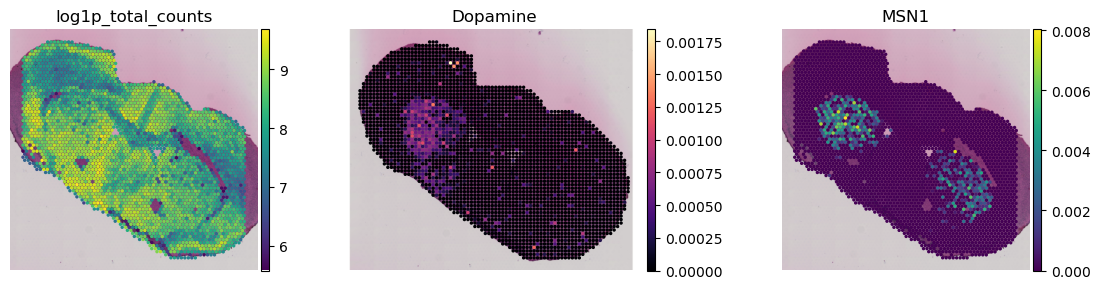

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

sc.pl.spatial(rna, color='log1p_total_counts', ax=axes[0], **kwargs, show=False)
sc.pl.spatial(msi, color='Dopamine', cmap='magma', ax=axes[1], **kwargs, show=False)
sc.pl.spatial(ct, color='MSN1', cmap='viridis', ax=axes[2], **kwargs, show=False)

fig.subplots_adjust(wspace=0, hspace=0)
fig.tight_layout()

/tmp/ipykernel_91083/2138788489.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


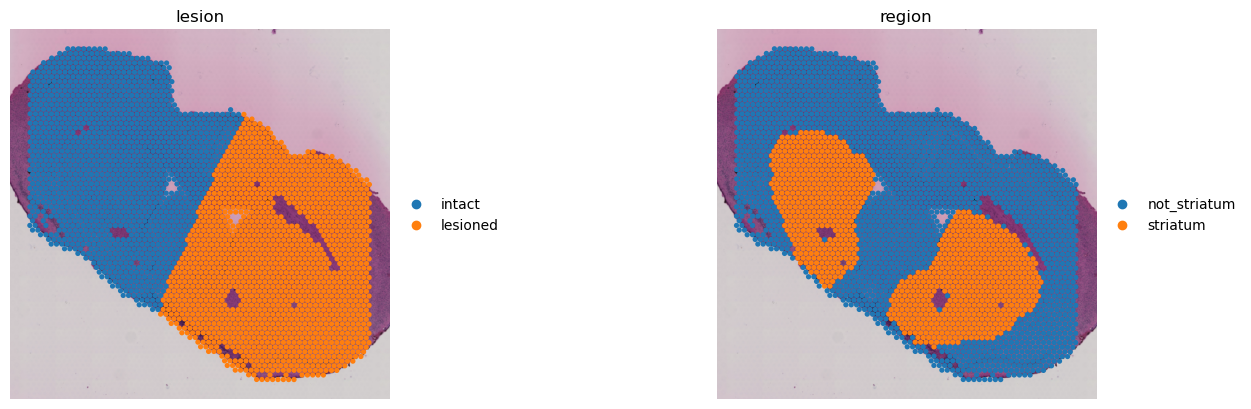

In [9]:
sc.pl.spatial(rna, color=['lesion', 'region'], **kwargs, wspace=0.25)

Tutaj jest ta agregacaj danych multimodalnych, ale nie rozumie mtej filtracji

In [ ]:
# li.mt.rank_aggregate(adata=mdata,
#                      groupby='celltype',
#                      # pass our modified resource
#                      resource=resource,
#                      # NOTE: Essential arguments when handling multimodal data
#                      mdata_kwargs={
#                      # Ligand-Receptor pairs are directed so we need to correctly pass
#                      # `RNA` with ligands as `x_mod` and receptors as `y_mod`
#                      'x_mod': 'rna',
#                      'y_mod': 'prot',
#                      # We use .X from the x_mod
#                      'x_use_raw':False,
#                      # We use .X from the y_mod
#                      'y_use_raw':False,
#                      # NOTE: we need to ensure that the modalities are correctly transformed
#                      'x_transform':li.ut.zi_minmax,
#                      'y_transform':li.ut.zi_minmax,
#                     },
#                   verbose=True
#                   )

Filtracja genów 

In [11]:
sc.pp.highly_variable_genes(rna, flavor='cell_ranger', n_top_genes=5000)
sc.pp.highly_variable_genes(msi, flavor='cell_ranger', n_top_genes=150)
ct.var['cv'] = ct.X.toarray().var(axis=0) / ct.X.toarray().mean(axis=0)
ct.var['highly_variable'] = ct.var['cv'] > np.percentile(ct.var['cv'], 20)

In [12]:
msi = msi[:, msi.var['highly_variable']]
rna = rna[:, rna.var['highly_variable']]
ct = ct[:, ct.var['highly_variable']]

In [13]:
# co robi to ???
sc.pp.scale(msi, max_value=5)

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.


In [14]:
metalinks = li.rs.get_metalinks(tissue_location='Brain',
                                biospecimen_location='Cerebrospinal Fluid (CSF)',
                                source=['CellPhoneDB', 'NeuronChat']
                                )
metalinks.head()

Database downloaded and saved to /home/maxi7524/repositories/MSB/metalinksdb.db (13910016 bytes).


,hmdb,uniprot,gene_symbol,metabolite,mor,transport_direction,type,source
0,HMDB0000870,P25021,HRH2,Histamine,0,None,lr,CellPhoneDB
1,HMDB0000870,P25021,HRH2,Histamine,1,None,lr,CellPhoneDB
2,HMDB0000870,P35367,HRH1,Histamine,0,None,lr,CellPhoneDB
3,HMDB0000870,P35367,HRH1,Histamine,1,None,lr,CellPhoneDB
4,HMDB0000870,Q9H3N8,HRH4,Histamine,0,None,lr,CellPhoneDB


In [15]:
map_df = li.rs.get_hcop_orthologs(columns=['human_symbol', 'mouse_symbol'],
                                  min_evidence=3
                                  ).rename(columns={'human_symbol':'source',
                                                   'mouse_symbol':'target'})

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/liana/resource/_orthology.py:204: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [16]:
metalinks = li.rs.translate_column(resource=metalinks,
                                   map_df=map_df,
                                   column='gene_symbol',
                                   one_to_many=1)
metalinks.head()

,hmdb,uniprot,gene_symbol,metabolite,mor,transport_direction,type,source
0,HMDB0000870,P25021,Hrh2,Histamine,0,None,lr,CellPhoneDB
1,HMDB0000870,P25021,Hrh2,Histamine,1,None,lr,CellPhoneDB
2,HMDB0000870,P35367,Hrh1,Histamine,0,None,lr,CellPhoneDB
3,HMDB0000870,P35367,Hrh1,Histamine,1,None,lr,CellPhoneDB
4,HMDB0000870,Q9H3N8,Hrh4,Histamine,0,None,lr,CellPhoneDB


In [21]:
receptors = np.intersect1d(metalinks['gene_symbol'].unique(), rna.var_names)
rec = rna[:, receptors].copy()

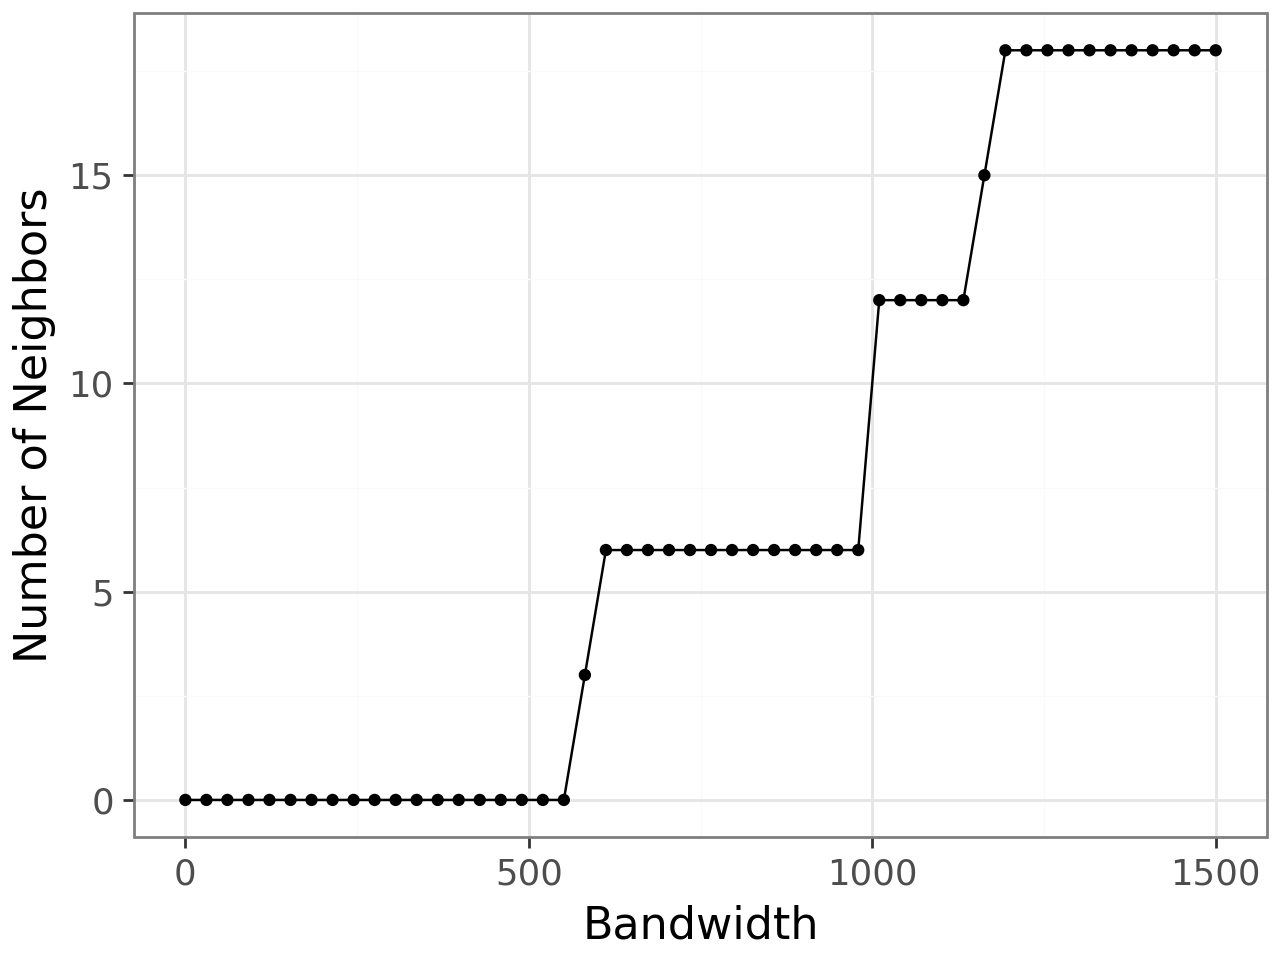

In [22]:
plot, _ = li.ut.query_bandwidth(coordinates=rna.obsm['spatial'], start=0, end=1500)
plot

In [23]:
bandwidth = 500
cutoff = 0.1
# distances of metabolties to RNA
reference = mdata.mod["msi"].obsm["spatial"]

In [24]:
li.ut.spatial_neighbors(ct, bandwidth=bandwidth, cutoff=cutoff, spatial_key="spatial", reference=reference, set_diag=False, standardize=False)
li.ut.spatial_neighbors(rec, bandwidth=bandwidth, cutoff=cutoff, spatial_key="spatial", reference=reference, set_diag=False, standardize=False)

In [25]:
# MISTy
mdata.update_obs()
misty = li.mt.MistyData({"intra": msi, "receptor": rec, "ct": ct}, enforce_obs=False, obs=mdata.obs)
misty

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_

MuData object with n_obs × n_vars = 6041 × 207
  obs:	'rna:in_tissue', 'rna:array_row', 'rna:array_col', 'rna:x', 'rna:y', 'rna:lesion', 'rna:region', 'rna:n_genes_by_counts', 'rna:log1p_n_genes_by_counts', 'rna:total_counts', 'rna:log1p_total_counts', 'rna:pct_counts_in_top_50_genes', 'rna:pct_counts_in_top_100_genes', 'rna:pct_counts_in_top_200_genes', 'rna:pct_counts_in_top_500_genes', 'rna:total_counts_mt', 'rna:log1p_total_counts_mt', 'rna:pct_counts_mt', 'rna:n_genes', 'rna:n_counts', 'msi:x', 'msi:y', 'msi:array_row', 'msi:array_col', 'msi:leiden', 'msi:n_counts', 'msi:index_right', 'msi:region', 'msi:lesion'
  var:	'highly_variable'
  3 modalities
    intra:	3005 x 150
      obs:	'x', 'y', 'array_row', 'array_col', 'leiden', 'n_counts', 'index_right', 'region', 'lesion'
      var:	'mean', 'std', 'mz', 'max_intensity', 'mz_raw', 'annotated', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'hvg'
      obsm:	'X_pca', 'spatial'
      varm:	'PCs'
      layers:	'raw'
      obsp:	'connectivities', 'distances'
    receptor:	3036 x 19
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'lesion_colors', 'log1p', 'region_colors', 'spatial', 'hvg'
      obsm:	'spatial', 'spatial_connectivities'
      varm:	'weighted'
      layers:	'counts'
    ct:	3036 x 38
      obs:	'in_tissue', 'array_row', 'array_col', 'x', 'y', 'lesion', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'uniform_density', 'rna_count_based_density'
      var:	'cv', 'highly_variable'
      uns:	'lesion_colors', 'log1p', 'overlap_genes', 'region_colors', 'spatial', 'training_genes'
      obsm:	'spatial', 'tangram_ct_pred', 'spatial_connectivities'
      varm:	'weighted'

In [26]:
misty(model=li.mt.sp.LinearModel, verbose=True, bypass_intra=True, maskby='lesion')

Now learning: 1048.38 masked by lesioned: 100%|██████████| 150/150 [00:41<00:00,  3.63it/s]


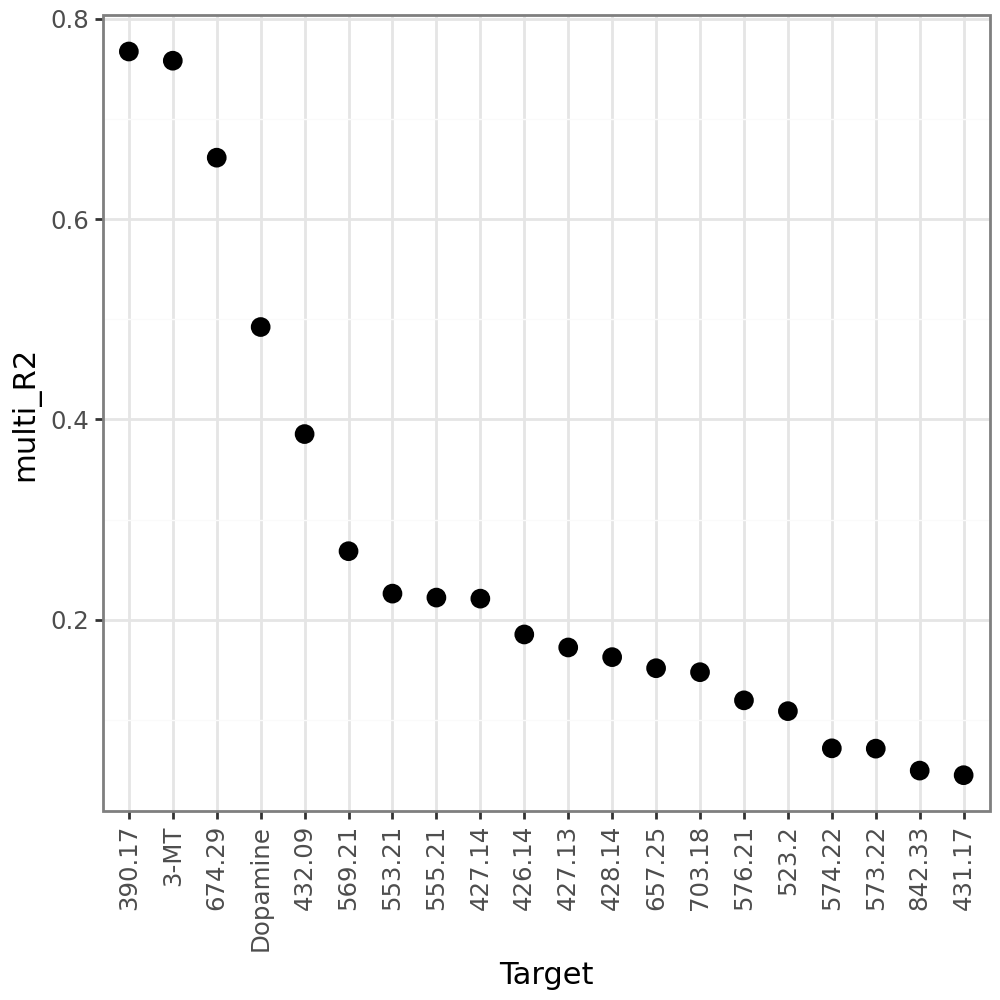

In [27]:
li.pl.target_metrics(misty, stat='multi_R2', return_fig=True, top_n=20, filter_fun=lambda x: x['intra_group']=='intact')

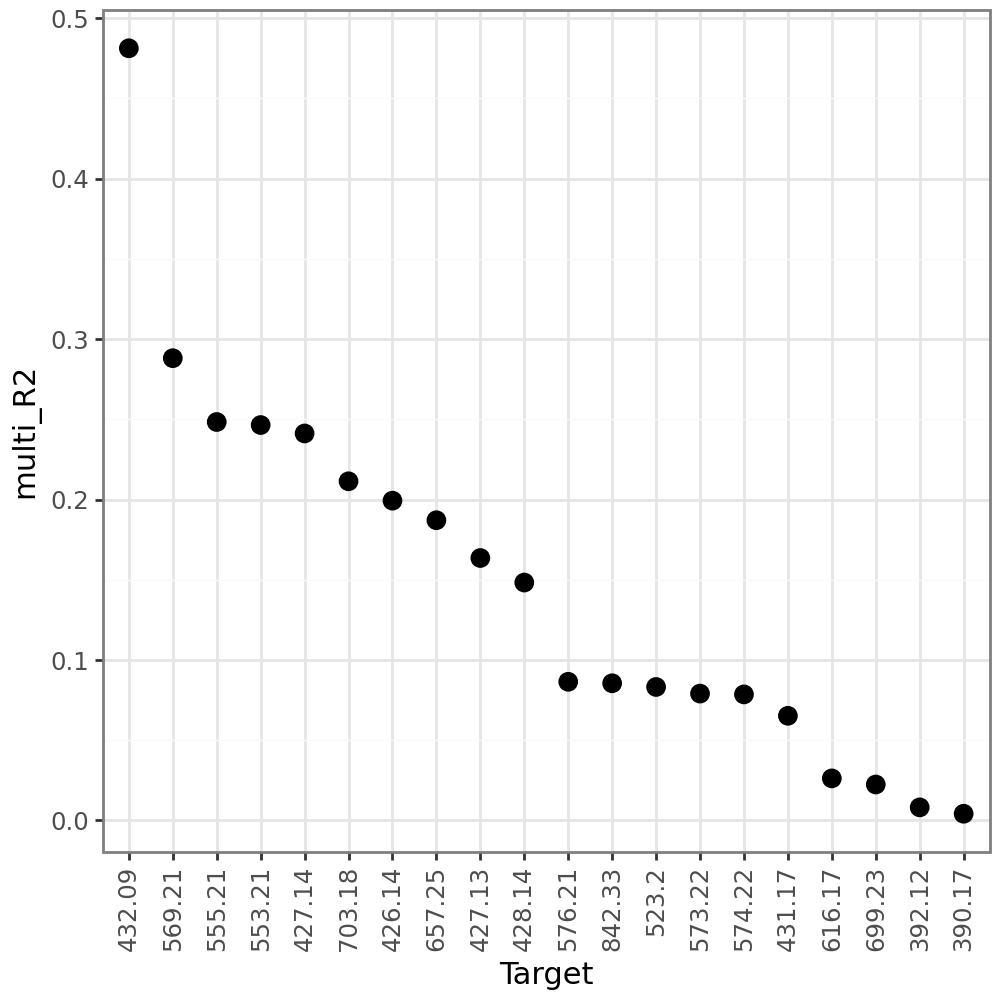

In [28]:
li.pl.target_metrics(misty, stat='multi_R2', return_fig=True, top_n=20, filter_fun=lambda x: x['intra_group']=='lesioned')